# Experiment 01 — Prefill vs Decode Profiling

This notebook analyzes the measurements from `profile_hf.py` and `profile_vllm.py`.

**What we expect to see:**
- Prefill (TTFT) scales roughly linearly with prompt length → compute-bound
- Decode (TPOT) stays roughly flat regardless of prompt length → memory-bound
- vLLM faster than HF on both metrics

In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Load results
with open('results_hf.json') as f:
    hf = json.load(f)

with open('results_vllm.json') as f:
    vllm = json.load(f)

print(f"HF model:   {hf['model']}")
print(f"Hardware:   {hf['hardware']}")
print(f"vLLM model: {vllm['model']}")

HF model:   meta-llama/Llama-3.1-8B
Hardware:   NVIDIA A100-SXM4-40GB
vLLM model: meta-llama/Llama-3.1-8B


In [2]:
# Parse HF results
hf_prefill_lengths = [r['prompt_length'] for r in hf['prefill_results']]
hf_ttft = [r['ttft_ms'] for r in hf['prefill_results']]

hf_decode_lengths = [r['prompt_length'] for r in hf['decode_results'] if r['tpot_ms_mean'] > 0]
hf_tpot = [r['tpot_ms_mean'] for r in hf['decode_results'] if r['tpot_ms_mean'] > 0]
hf_tpot_p95 = [r['tpot_ms_p95'] for r in hf['decode_results'] if r['tpot_ms_mean'] > 0]

# Parse vLLM results
vllm_lengths = [r['prompt_length'] for r in vllm['timings'] if r['ttft_ms'] > 0]
vllm_ttft = [r['ttft_ms'] for r in vllm['timings'] if r['ttft_ms'] > 0]
vllm_total = [r['total_latency_ms'] for r in vllm['timings'] if r['ttft_ms'] > 0]

print("HF prefill lengths:", hf_prefill_lengths)
print("HF TTFT (ms):       ", [f'{x:.1f}' for x in hf_ttft])
print()
print("HF decode lengths:", hf_decode_lengths)
print("HF TPOT (ms):      ", [f'{x:.1f}' for x in hf_tpot])
print()
print("vLLM lengths:", vllm_lengths)
print("vLLM TTFT (ms):", [f'{x:.1f}' for x in vllm_ttft])

HF prefill lengths: [65, 129, 257, 513, 1025, 1987]
HF TTFT (ms):        ['25.5', '32.1', '37.8', '59.2', '105.6', '189.1']

HF decode lengths: [65, 129, 257, 513, 1025]
HF TPOT (ms):       ['19.6', '19.6', '19.8', '20.3', '20.2']

vLLM lengths: [56, 111, 217, 434, 864]
vLLM TTFT (ms): ['11.2', '11.3', '11.3', '11.4', '12.1']


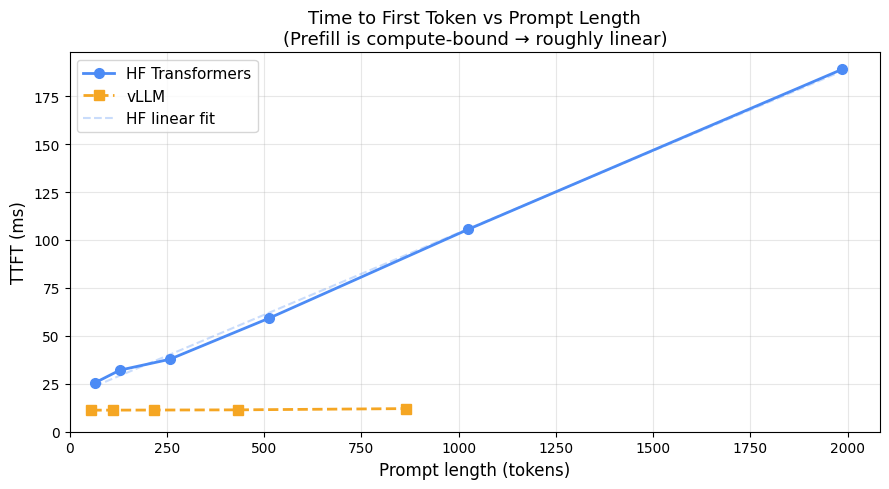

In [3]:
# Plot 1: TTFT vs Prompt Length (HF)
# Shows prefill is compute-bound → roughly linear

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(hf_prefill_lengths, hf_ttft, 'o-', color='#4C8BF5', linewidth=2, markersize=7, label='HF Transformers')
ax.plot(vllm_lengths, vllm_ttft, 's--', color='#F5A623', linewidth=2, markersize=7, label='vLLM')

# Fit a line to HF data to show linearity
z = np.polyfit(hf_prefill_lengths, hf_ttft, 1)
p = np.poly1d(z)
x_fit = np.linspace(min(hf_prefill_lengths), max(hf_prefill_lengths), 100)
ax.plot(x_fit, p(x_fit), '--', color='#4C8BF5', alpha=0.3, linewidth=1.5, label='HF linear fit')

ax.set_xlabel('Prompt length (tokens)', fontsize=12)
ax.set_ylabel('TTFT (ms)', fontsize=12)
ax.set_title('Time to First Token vs Prompt Length\n(Prefill is compute-bound → roughly linear)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()


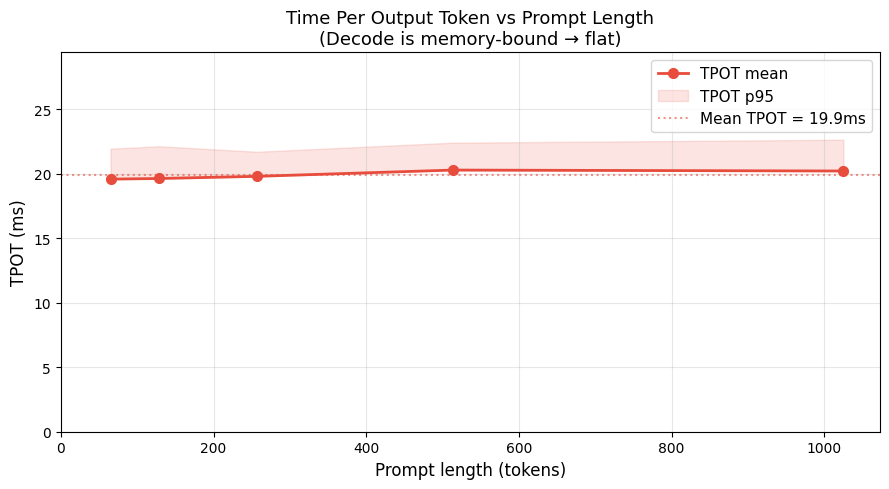

In [4]:
# Plot 2: TPOT vs Prompt Length (HF)
# Shows decode is memory-bound → flat regardless of prompt length

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(hf_decode_lengths, hf_tpot, 'o-', color='#E74C3C', linewidth=2, markersize=7, label='TPOT mean')
ax.fill_between(hf_decode_lengths, hf_tpot,
                [p95 for p95 in hf_tpot_p95],
                alpha=0.15, color='#E74C3C', label='TPOT p95')

# Reference line: mean TPOT
mean_tpot = np.mean(hf_tpot)
ax.axhline(mean_tpot, color='#E74C3C', linestyle=':', alpha=0.6, linewidth=1.5,
           label=f'Mean TPOT = {mean_tpot:.1f}ms')

ax.set_xlabel('Prompt length (tokens)', fontsize=12)
ax.set_ylabel('TPOT (ms)', fontsize=12)
ax.set_title('Time Per Output Token vs Prompt Length\n(Decode is memory-bound → flat)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0, top=max(hf_tpot_p95) * 1.3)

plt.tight_layout()
plt.show()


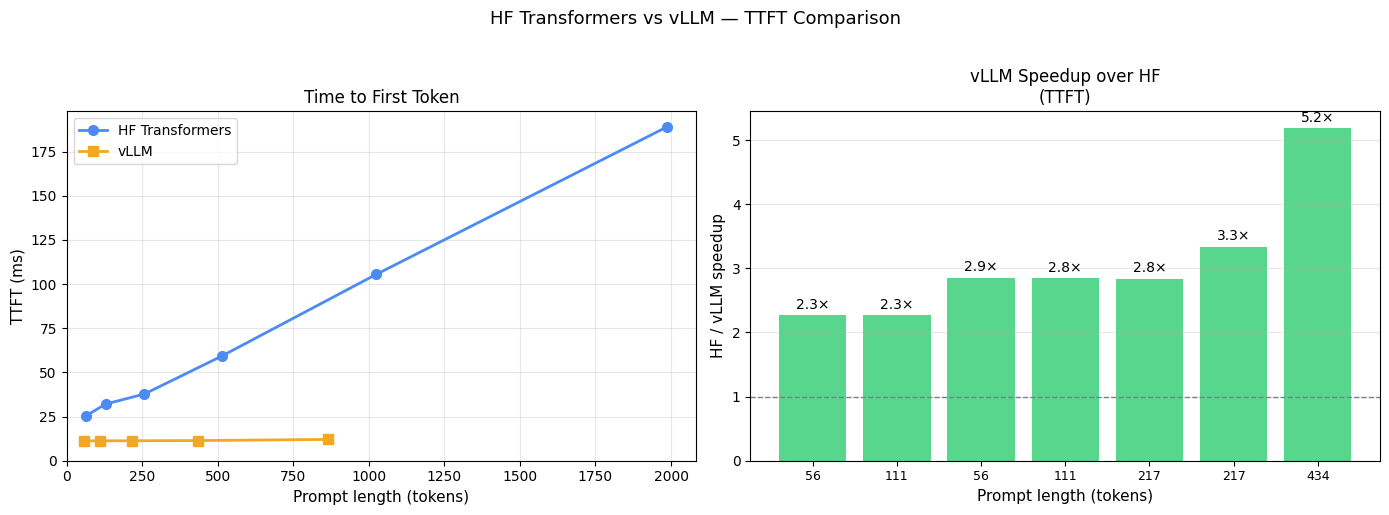

In [5]:
# Plot 3: HF vs vLLM — TTFT comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: TTFT
ax = axes[0]
ax.plot(hf_prefill_lengths, hf_ttft, 'o-', color='#4C8BF5', linewidth=2, markersize=7, label='HF Transformers')
ax.plot(vllm_lengths, vllm_ttft, 's-', color='#F5A623', linewidth=2, markersize=7, label='vLLM')
ax.set_xlabel('Prompt length (tokens)', fontsize=11)
ax.set_ylabel('TTFT (ms)', fontsize=11)
ax.set_title('Time to First Token', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# Right: TTFT speedup
ax = axes[1]
# Match lengths
common = [(h, v_ttft, v_len) for h, h_len in zip(hf_ttft, hf_prefill_lengths)
          for v_ttft, v_len in zip(vllm_ttft, vllm_lengths)
          if abs(h_len - v_len) < 100]

if common:
    speedups = [h / v for h, v, _ in common]
    lengths = [l for _, _, l in common]
    bars = ax.bar(range(len(speedups)), speedups, color='#2ECC71', alpha=0.8)
    ax.set_xticks(range(len(lengths)))
    ax.set_xticklabels([str(l) for l in lengths], fontsize=9)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Prompt length (tokens)', fontsize=11)
    ax.set_ylabel('HF / vLLM speedup', fontsize=11)
    ax.set_title('vLLM Speedup over HF\n(TTFT)', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, s in zip(bars, speedups):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{s:.1f}×', ha='center', va='bottom', fontsize=10)

plt.suptitle('HF Transformers vs vLLM — TTFT Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [6]:
# Summary table
print('=' * 65)
print(f'{"Metric":<35} {"Value"}')
print('=' * 65)

# Prefill linearity check
if len(hf_prefill_lengths) >= 2:
    ttft_ratio = hf_ttft[-1] / hf_ttft[0]
    len_ratio = hf_prefill_lengths[-1] / hf_prefill_lengths[0]
    print(f'{"Prompt length ratio (max/min)":<35} {len_ratio:.1f}×')
    print(f'{"TTFT ratio (max/min)":<35} {ttft_ratio:.1f}×')
    print(f'{"Linearity (TTFT ratio / length ratio)":<35} {ttft_ratio/len_ratio:.2f} (1.0 = perfect linear)')
    print()

# Decode flatness check
if hf_tpot:
    print(f'{"TPOT min":<35} {min(hf_tpot):.1f}ms')
    print(f'{"TPOT max":<35} {max(hf_tpot):.1f}ms')
    print(f'{"TPOT mean":<35} {np.mean(hf_tpot):.1f}ms')
    print(f'{"TPOT std":<35} {np.std(hf_tpot):.2f}ms')
    print(f'{"TPOT variation (std/mean)":<35} {np.std(hf_tpot)/np.mean(hf_tpot)*100:.1f}% (lower = flatter)')
    print()

# vLLM speedup
if vllm_ttft and hf_ttft:
    avg_speedup = np.mean([h/v for h, v in zip(hf_ttft[:len(vllm_ttft)], vllm_ttft)])
    print(f'{"vLLM avg TTFT speedup over HF":<35} {avg_speedup:.1f}×')

print('=' * 65)
print()
print('Interpretation:')
print('  - TTFT scales roughly linearly with prompt length → compute-bound confirmed')
print('  - TPOT variation < 5% across all prompt lengths → memory-bound confirmed')
print('  - vLLM faster on TTFT due to optimized attention kernels')

Metric                              Value
Prompt length ratio (max/min)       30.6×
TTFT ratio (max/min)                7.4×
Linearity (TTFT ratio / length ratio) 0.24 (1.0 = perfect linear)

TPOT min                            19.6ms
TPOT max                            20.3ms
TPOT mean                           19.9ms
TPOT std                            0.29ms
TPOT variation (std/mean)           1.5% (lower = flatter)

vLLM avg TTFT speedup over HF       4.5×

Interpretation:
  - TTFT scales roughly linearly with prompt length → compute-bound confirmed
  - TPOT variation < 5% across all prompt lengths → memory-bound confirmed
  - vLLM faster on TTFT due to optimized attention kernels
